In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

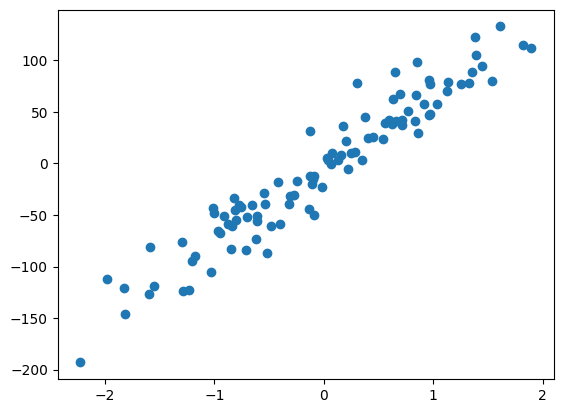

In [4]:
plt.scatter(X,y)

In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [6]:
m = model.coef_
print(m)


[70.92866927]


In [7]:
b = model.intercept_
print(b)

-3.4813096621406263


In [8]:
# lets create a class which is used to reach the 'b' value from random value the formula is : y = m*X+b
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = 39.05
        self.b = -100
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        for i in range(self.epochs):
            loss_slope = -2 * np.mean(y-self.m*X.ravel() - self.b)
            self.b = self.b - (self.lr * loss_slope) #this () tells us the abut the stepsize means it called as stepsize
            print(loss_slope,self.b)
        print(self.b)
        

In [9]:
gd = GDRegressor(0.1,25)

In [10]:
gd.fit(X,y)

-191.62851779825786 -80.83714822017421
-153.3028142386063 -65.50686679631359
-122.64225139088504 -53.242641657225086
-98.113801112708 -43.431261545954285
-78.49104089016643 -35.582157456937644
-62.79283271213315 -29.302874185724328
-50.234266169706515 -24.279447568753675
-40.18741293576521 -20.260706275177153
-32.14993034861217 -17.045713240315933
-25.719944278889724 -14.473718812426961
-20.575955423111772 -12.416123270115783
-16.460764338489422 -10.77004683626684
-13.168611470791543 -9.453185689187684
-10.534889176633225 -8.399696771524361
-8.42791134130658 -7.556905637393704
-6.742329073045263 -6.882672730089177
-5.393863258436211 -6.343286404245556
-4.31509060674897 -5.911777343570659
-3.4520724853991775 -5.566570095030741
-2.76165798831934 -5.290404296198807
-2.2093263906554728 -5.06947165713326
-1.767461112524379 -4.892725545880822
-1.413968890019501 -4.751328656878872
-1.1311751120156008 -4.638211145677312
-0.904940089612483 -4.547717136716064
-4.547717136716064


**NOW LETS PREDICT THE VALUE OF REAL{M} AND {B} WITH THE HELP OF RANDOM INIT VALUES**

In [11]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [12]:
X,y = make_regression(n_samples = 100,n_features=1,n_informative=1,n_targets=1,noise=0.1,random_state=12)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=12)

In [14]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [16]:
m = model.coef_
print(m)

[35.56107984]


In [17]:
b = model.intercept_
print(b)

-0.005722736664405481


In [18]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -50
        self.lr = learning_rate
        self.ep = epochs

    def fit(self,X,y):
        for i in range(self.ep):
            b_slope = -2 * np.mean(y - self.m * X.ravel() - self.b)
            m_slope = -2 * np.mean((y - self.m * X.ravel() - self.b)*X.ravel())
            self.b = self.b - (self.lr * b_slope)
            self.m = self.m - (self.lr * m_slope)
            print(self.m,self.b)

    def predict(self,X):
        return self.m * X + self.b

In [19]:
gd = GDRegressor(0.1,100)

In [20]:
gd.fit(X_train,y_train)

85.71332411848384 -37.95244622146778
74.62475874401343 -28.768617652998714
66.01309372622563 -21.77409213531529
59.32066987603776 -16.45226128282704
54.116135101199546 -12.407567974152867
50.06570795655781 -9.337280433945622
46.91100088292081 -7.009825112613387
44.451902073214946 -5.248158053019626
42.53335901274287 -3.917006218477572
41.035171860237526 -2.9130807443555904
39.86410911678278 -2.1575720370888556
38.947815446412136 -1.5903965189157094
38.23010282825963 -1.165787711545265
37.66730972458177 -0.8489188108873573
37.22548502593255 -0.6133164993407243
36.87820910151873 -0.43888152609350833
36.604907126958125 -0.3103744464303102
36.38954290106665 -0.21625783733213563
36.21960684571045 -0.14781159727175333
36.08533153998789 -0.09845736044091627
35.97908330643042 -0.06324296855330089
35.8948900707798 -0.038449391508758896
35.82807475063701 -0.02129127461827963
35.77497040263917 -0.009689032011636432
35.732698743590745 -0.0020955776527808506
35.69899782109187 0.002635248398565087
3

In [21]:
y_pred = gd.predict(X_test)
r2_score(y_test,y_pred)

0.9999960040436603

In [33]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [34]:
b = -520
m = 600
lr = 0.001
all_b = []
all_m = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope_b = 0
    slope_m = 0
    cost = 0
    for j in range(X.shape[0]):
        slope_b = slope_b - 2*(y[j] - (m * X[j]) -  b)
        slope_m = slope_m - 2*(y[j] - (m * X[j]) -  b)*X[j]
        cost = cost + (y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

In [35]:
fig, ax = plt.subplots(figsize=(9,5))
#fig.set_tight_layout(True)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*(-27) -150
ax.scatter(X, y)
line, = ax.plot(x_i, x_i*50 - 4, 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*all_m[i] + all_b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)


<IPython.core.display.Javascript object>